# 5 - Information Retrieval
## CSCI E-108
### Steve Elston

## Introduction

Document search is a core data mining methodology. For example, document search is an essential component of solutions like web search, recommender systems and RAG algorithms for constraining results from large language models.  

This notebook contains a simple example of vector document search. The search approach used in this notebook is deliberately restricted. A real-world solution would be considerably more complex. In this case, the search is performed in two simple stages.    
1. An approximate vector search using a scaleable index.
2. A reranking or refinement step using a more exact, but slower algorithm, applied the results of the first search.   

These steps can both be accomplished with dense text embedding. In other cases a hybrid of sparse and dense embedding methods is applied.  

As one might expect, production quality search systems require a great deal more sophistication than is applied here. Further, we pursue only one of many possible architectures to this problem.

The approach we use for retrieval here is truly unsupervised. We have no known rankings. For these situations, evaluation of retrieval solutions presents a significant problem. Indeed we have no objective basis for evaluation. Even if we went to the time and expense of creating a limited set of human rankings, the result would likely be biased in some way. An alternative is to compare these results to other approaches. For example, one could compare rankings to those produced by one or more LLMs. Even here, there is no way to know how good or biased the valuation performed is. In the interest of simplicity and limited effort, we will not attempt any evaluation here. Rather, we are limited to some subjective evaluation.       

### Unsupervised vector text search

As you work though this notebook, you may notice that something is missing. There is no objective evaluation. Ideally, one would want to compare models using metrics like recall and precision to evaluate the search. In this case, we have no labeled cases, so we will proceed on a fully unsupervised basis.  

## Setup

In this section, you will perform the setup steps required to execute the remainder of this notebook. This notebook is intended to run in Google Colab using a GPU. Access to a [Google Docs](https://workspace.google.com/products/drive/) account is also required. If you are not familiar with working in Colab you can find a [quick start guide here](https://docs.google.com/document/d/1afPjc4IaeZzIqUAX20uBEk3Dt41pAP0Ebkpd53EJTaE/edit?tab=t.0).   

To configure the colab runtime environment click the Change runtime type under the Runtime menu tab. Select a GPU type for execution.   

### Package installation and imports

As a first step, install the required packages by executing the code in the cell below.  

> **Note 1:** Execution of this notebook using A100 GPU on Google Colab Pro+ requires about 4 hours of GPU time and 1 hour of wall-clock time.  
>
> **Note 2:** There are multiple possible version conflicts which arise when creating an environment where FAISS runs. You may well see errors from the pip installer. If this occurs you need to click `Restart session` under the Runtime menu tab and execute the code in the cell below again.

In [1]:
!pip install -qU \
    sentence-transformers \
    torch==2.6.0 \
    pandas==2.2.2 \
    datasets==2.12.0 \
    pyarrow<20.0.0a0\
    numpy==2.2

!pip install rank-bm25
!pip install faiss-gpu-cu12
!pip install pinecone-text

/bin/bash: line 1: 20.0.0a0: No such file or directory


Once you have successfully installed the required packages, execute the code in the cell below to perform the imports. As verification your your runtime environment you should see two messages:  
1. An indication that you are running on Cuda, and therefore using GPU acceleration.    
2. Confirmation that you Google Doc drive has been mounted.    

In [2]:
import numpy as np
import pandas as pd
import faiss
from rank_bm25 import BM25Okapi

import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import torch
import textwrap
import matplotlib.pyplot as plt


from sentence_transformers import SentenceTransformer, CrossEncoder

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"running on {device}")

from google.colab import drive
drive.mount('/content/drive')

running on cuda
Mounted at /content/drive


### Loading and exploring the data file   

Before proceeding you must do the following:   
1. Download the zipped data file from the [Wikipedia Movie Plots](https://www.kaggle.com/datasets/jrobischon/wikipedia-movie-plots) page.     
2. Unzip the file.
3. Place the unzipped file in your Google Drive file system. You can place this file at the top level or in a directory.     
4. In the code cell below edit the `file_path` variable to match the location and name of your unzipped file. For example, if you file is named `wiki_movie_plots.csv` and is in a directory called `CSCIS108`, the full path name is `"/content/drive/MyDrive/CSCIS109/wiki_movie_plots.csv"`.

With the foregoing steps completed, run the code in the cell below to load the file. You should see the 8 column names printed as a verification of the loading.

In [6]:
file_path = "/content/drive/MyDrive/E108/wiki_movie_plots_deduped.csv"
movie_plots = pd.read_csv(file_path, on_bad_lines='skip')  # Added to fix a ParseError
print(movie_plots.shape)
print(movie_plots.columns)

(34886, 8)
Index(['Release Year', 'Title', 'Origin/Ethnicity', 'Director', 'Cast',
       'Genre', 'Wiki Page', 'Plot'],
      dtype='object')


To get a feel for what these data look like, execute the code in the cell below to display the title and plot summary of a few movies.  

In [7]:
def print_movies(movies, line_length=100):
  if isinstance(movies, pd.Series):
    print(movies.loc['Title'])
    print(textwrap.fill(movies.loc['Plot'],  width=line_length))
    print('\n')
  else:
    for i in range(len(movies)):
      print(movies.loc[i,'Title'])
      print(textwrap.fill(movies.loc[i,'Plot'],  width=line_length))
      print('\n')

print_movies(movie_plots.iloc[:10,:])

Kansas Saloon Smashers
A bartender is working at a saloon, serving drinks to customers. After he fills a stereotypically
Irish man's bucket with beer, Carrie Nation and her followers burst inside. They assault the Irish
man, pulling his hat over his eyes and then dumping the beer over his head. The group then begin
wrecking the bar, smashing the fixtures, mirrors, and breaking the cash register. The bartender then
sprays seltzer water in Nation's face before a group of policemen appear and order everybody to
leave.[1]


Love by the Light of the Moon
The moon, painted with a smiling face hangs over a park at night. A young couple walking past a
fence learn on a railing and look up. The moon smiles. They embrace, and the moon's smile gets
bigger. They then sit down on a bench by a tree. The moon's view is blocked, causing him to frown.
In the last scene, the man fans the woman with his hat because the moon has left the sky and is
perched over her shoulder to see everything better.


The 

Notice that the plot summaries are all in unstructured natural language format.   

> **Note:** In the interest of brevity, we are truncating the exploration process at this point. Examples of further exploration we would normally perform include:  
> 1. Using ordered bar charts, often on a log scale, to explore the frequency of words in the corpus and the queries.
> 2. Examining the distribution of simple Jaccard similarity between a sample of the documents and queries.   
> 3. Performing the foregoing explorations with the sample stratified by other attributes like genre, range of release year, etc.  

## Preprocessing the Plot Text     

While not our focus here, we will follow basic common practice of preparing text data for natual language processing (NLP). These steps are:       
1. All characters are set to lower case, so the same word is considered two.   
2. Numbers are removed since they generally do not have semmantic meaning.     
3. Commonly used words with limited semantic value, such as conjunctives, know as [**stop words**](https://en.wikipedia.org/wiki/Stop_word), are removed.    

In a production scale system these processes can be parallelized quite readily. Execute this code and examine the results.   

In [8]:
def preprocess_text(text_list):
    """
    Preprocesses a list of text strings for use with Sentence Transformers.

    Args:
        text_list (list): A list of strings, where each string is a sentence or text segment.

    Returns:
        list: A list of preprocessed strings.
    """
    preprocessed_texts = []
    stop_words = set(stopwords.words('english'))

    for text in text_list:
        # Set characters to lowercasing
        text = text.lower()

        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))

        # Remove numbers
        text = re.sub(r'\d+', '', text)

        # Tokenization to words and then stop word removal
        words = word_tokenize(text)
        words = [word for word in words if word not in stop_words]
        preprocessed_text = ' '.join(words)

        # Remove extra whitespace
        preprocessed_text = ' '.join(preprocessed_text.split())

        preprocessed_texts.append(preprocessed_text)

    return preprocessed_texts


## Make sure we have the nltk stop words downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

## Download the nltk punkt tokenizer
#import nltk
nltk.download('punkt_tab')

%time movie_plots.loc[:,'Plot'] = preprocess_text(movie_plots.loc[:,'Plot'])
print_movies(movie_plots.loc[:3,:])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


CPU times: user 43.6 s, sys: 1.44 s, total: 45.1 s
Wall time: 45.1 s
Kansas Saloon Smashers
bartender working saloon serving drinks customers fills stereotypically irish mans bucket beer
carrie nation followers burst inside assault irish man pulling hat eyes dumping beer head group
begin wrecking bar smashing fixtures mirrors breaking cash register bartender sprays seltzer water
nations face group policemen appear order everybody leave


Love by the Light of the Moon
moon painted smiling face hangs park night young couple walking past fence learn railing look moon
smiles embrace moons smile gets bigger sit bench tree moons view blocked causing frown last scene
man fans woman hat moon left sky perched shoulder see everything better


The Martyred Presidents
film minute long composed two shots first girl sits base altar tomb face hidden camera center altar
viewing portal displays portraits three us presidents—abraham lincoln james garfield william
mckinley—each victims assassination seco

## Vector Search   

You will now employ an approximate vector similarity search on the movie plots to perform searches for similar movies. Searches can be performed in two ways which are a component of **content-based recommender algorithms**.   
1. Finding movies with semantically similar plots to a current movie.    
2. Finding movies with semantically similar plots to a use query.    

The vector similarity search requires two steps.    
1. First, the the natural language of the plot summaries are transformed to embedding vectors. To perform the similarity search, the natural language queries are transformed to the same embedding space.     
2. Efficient approximate nearest neighbor search algorithms search indexes will be applied to the search on the embedding vectors.

> **Exercise 5-01:** One might well ask, why not use an LLM to perform the document search? There are two significant reasons. One reason is the slow query speed of the LLM, which can lead to significant lag is a great number of queries must be process. The other reason is cost. Consider a use case for a small scale business application with the following parameters:
>   - $10^6$ shards of 500 tokens each are uploaded (updated) daily to the corpus.
>   - $10^6$ queries per day with average query length of 500 tokens.
>   - Generated results of 500 tokens per query.
>   - Cost to upload 1 million tokens is $.10.
>  - Cost to generate 1 million tokens $1.00.
> 1. What is the daily cost for this system?
> 2. What is the annual cost for 250 business days per year?
> 3. For a medium size business unit with revenue of $10 million per year how significant is this cost?    

> **Answer:**
> 
> 1. Daily cost:
>     - Upload:  
>         - 10^6 shards × 500 tokens = 5 × 10^8 tokens  (corpus upload)
>         - 10^6 queries × 500 tokens = 5 × 10^8 tokens  (query upload)
>         - At $0.10 per 1M tokens: 2x(5 × 10^8) / 10^6 × $0.10 = 1x10^9 / 10^6 x $0.1 = $100/day  
>     - Generation: at $1.00 per 1M tokens: 5 × 10^8 / 10^6 × $1.00 = $500/day  
>     - Total daily cost: $50 (corpus upload) + $50 (query upload) + $500 (generated) = $600/day
> 
> 2. Annual cost: $600/day x 250days = $150.000/year
> 
> 3. This is about 1.5% of the revenue, which is a significant expense for the business.

### Create embeddings    

The [SentanceTransformers model](https://sbert.net/docs/sentence_transformer/pretrained_models.html) from the Transformers package is a model with several possible sets of pretrained weights. In the interest of fast execution, but mostly likely lower accuracy, we will use a small pretrained weight set. Cosine similarity is used since the embeddings are being computed for natural language.

The sentence transformers model includes a tokenizer. The embedding is computed from the first $m$ tokens encountered. As a result, long text sequences are truncated. To overcome this limitation we could shard the document and create embeddings for each shard. In the interest of simplicity, we skip this process here.  

> **Note 1:** Given the length of many of these plot summaries, it is likely that the number of tokens required exceeds the limit of the model. To some extent, this problem can be overcome by **sharding** the long text sequences. We will not do so here in the interest of simplicity and brevity.

> **Note 2:** There are a quite a few [**pretrained models**](https://sbert.net/docs/sentence_transformer/pretrained_models.html) available in the SentanceTransformers package. Finding the best model choice is a mater of considerable experimentation, which we skip here. We will use the `multi-qa-mpnet-base-dot-v1` which often provides good results for semantic similarity search problems. If you find that this large model executes too slowly or requires too much memory in your environment you can use the much smaller `all-MiniLM-L6-v2` model.

Execute the code in the cell below to download the weights and instantiate the model.   

In [9]:
#sentence_model = 'sentence-transformers/all-MiniLM-L6-v2'
sentence_model = 'sentence-transformers/multi-qa-mpnet-base-dot-v1'
model = SentenceTransformer(
    sentence_model,
    similarity_fn_name='cosine',
    device=device
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

To see the properties of this model, execute the code in the cell below.

In [10]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False, 'architecture': 'MPNetModel'})
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': True, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)

> **Exercise 5-02:** Examine the properties of the embedding model and answer these questions:
> 1. What is the maximum number of tokens processed by the model's tokenizer?
> 2. What limitation will this place on the embeddings given the plot summaries you have viewed and how do you think this limit will affect the similarity search?
> 3. How would sharding the plot summaries help this problem?  
> 4. How long are the embedding vectors produced?

> **Answers:**
> 1. `max_seq_length`: 512 tokens.        
> 2.  The embeddigs will truncate (basically ignore) everything after the first 512 tokens. This means the similarity search will emphasize the first part of the summaries, leading to potential information loss. What if two movies are very similar in the later part of the content? We may miss that.        
> 3.  By sharding, we would split the content into chunks of 512 tokens, and embed each chunk separately. Ideally, we would want to add some overlap between chunks to preserve some of the context. Then we store all the shard embeddings with some metadata, like the movie ID or shard number. The benefit of this process is that we are preserving all the content of the plots, and avoiding that information loss of the later parts of the content. With this, we can have potentially better matching, as each plot is represented in full.     
> 4. `word_embedding_dimension`: 768 dimensions          

The code in the cell below performs two operations.
1. We split the dataset into train and query (test) sets.
2. The natural language plots are embedded using the sentence transformers model.

Execute the code in the cell below and notice the dimensions of the two embedding arrays.

In [11]:
np.random.seed(4242)
movie_plots_train, movie_plots_test = train_test_split(movie_plots, test_size=0.03)
movie_plots_train.reset_index(inplace=True)
movie_plots_test.reset_index(inplace=True)
%time embeddings_test = model.encode(movie_plots_test.loc[:,'Plot'].to_numpy())
%time embeddings_train = model.encode(movie_plots_train.loc[:,'Plot'].to_numpy())
print(f"Dimensions of train embeddings: {embeddings_train.shape}  Dimensions of test embeddings: {embeddings_test.shape}")

CPU times: user 6.64 s, sys: 193 ms, total: 6.84 s
Wall time: 4.82 s
CPU times: user 3min 38s, sys: 1.76 s, total: 3min 40s
Wall time: 2min 21s
Dimensions of train embeddings: (33839, 768)  Dimensions of test embeddings: (1047, 768)


In [12]:
print(movie_plots_train.head())
print("\n\n\n\n")
print(movie_plots_test.head())

   index  Release Year                            Title Origin/Ethnicity  \
0  21790          1982                          Melanie         Canadian   
1   3749          1944                     Busy Buddies         American   
2  19367          1958                       Blind Spot          British   
3  24401          1955                       Char Paise        Bollywood   
4   6948          1957  Will Success Spoil Rock Hunter?         American   

        Director                                               Cast  \
0  Rex Bromfield                  Burton Cummings, Glynnis O'Connor   
1       Del Lord                                      Three Stooges   
2  Peter Maxwell                  Robert MacKenzie, Delphi Lawrence   
3     N. K. Ziri  Kishore Kumar, Shyama, Nimmi, Jayant, Johnny W...   
4  Frank Tashlin                      Tony Randall, Jayne Mansfield   

           Genre                                          Wiki Page  \
0          drama       https://en.wikipedia.o

### Build the index   

The code in the cell below constructs a composite index we will use for the scaleable similarity search. To ensure we are using a cosine metric we construct the composite index a step at a time in the `build_index` function. The index is built by these steps:    
1. The rotation process is defined.
2. An L2 or dot product search operator is defined.   
3. An inverted index coarse PQ quantizer using the dot product search is defined.   
4. A refinement search operator using the improved PQ algorithm is defined.
5. Finally, a flat refinement search is defined.   

Once the index is instantiated, the vectors are L2 normalized, the index is trained and the vectors are added to the index.  

Execute the code in the cell below and examine the training time and size.  

In [13]:
def get_memory(index, digits=2):
    # write index to file
    faiss.write_index(index, './temp.index')
    # get file size
    file_size = os.path.getsize('./temp.index')
    # delete saved index
    os.remove('./temp.index')
    return round(file_size/1000000, digits)

def build_index(D, m, nbits, nlist):
  # Initialize OPQ and coarse+fine quantizer steps
  opq = faiss.OPQMatrix(D, m)
  vecs = faiss.IndexFlatL2(D)
  # Define the subindex
  sub_index = faiss.IndexIVFPQ(vecs, D, nlist, m, nbits)
  # Define the index
  index = faiss.IndexPreTransform(opq, sub_index)
  # Add all of the previous steps to final refinement step
  index = faiss.IndexRefineFlat(index)
  return index

# L2 normalize the training vectors to get cosine distance from L2 dot product distance
faiss.normalize_L2(embeddings_train)

# Build the index
D=embeddings_train.shape[1]
m = 64
nbits = 8
nlist = 4096
index_IVFL2_PQ = build_index(D, m, nbits, nlist)

# Train the index and add the vectors
%time index_IVFL2_PQ.train(embeddings_train)
index_IVFL2_PQ.add(embeddings_train)
print(f'Index size: {get_memory(index_IVFL2_PQ)} MB')

CPU times: user 1h 50min 51s, sys: 2.31 s, total: 1h 50min 53s
Wall time: 11min 40s
Index size: 122.15 MB


> **Exercise 5-03:** We are using typical choice of **cosine similarity** between natural language embedding vectors. However, you will notice that L2 or dot product is used to specify the index. What step in the computation of the similarity search transforms to metric to cosine similarity and why?   

> **Answer:** 
> 
> It is the normalization step `faiss.normalize_L2(embeddings_train)`. 
> 
> The cosine similarity is defined as $d(x,x')=\frac{x \cdot x'}{\lVert x \rVert \lVert x' \rVert}$, and when we apply the L2 normalization, we guarantee that all vectors have unit length, so we know that $\lVert x \rVert =  \lVert x' \rVert = 1$ so $\lVert x \rVert \lVert x' \rVert = 1$ and the cosine similarity is just $x \cdot x'$, which is the L2 or dot product used to specify the index.

### Similarity search between movies

As a first exercise of the vector search index we will find the movies with the highest semantic similarity too one movie in the test dataset. Execute the code in the cell below to display the title and plot of this movie.  

In [14]:
print_movies(movie_plots_test.iloc[0,:])

One Hundred Men and a Girl
john cardwell adolphe menjou trombone player one large group unemployed musicians tries
unsuccessfully gain interview audition leopold stokowski disappoint daughter patricia patsy deanna
durbin tells managed get job stokowskis orchestra patsy soon learns truth also learns father
desperate rent money used cash ladys evening bag found pay debts irrepressible willful patsy seeks
interview mrs frost whose bag admits fathers actions mrs frost alice brady society matron wife rich
radio station owner john r frost eugene pallette lightheartedly offers sponsor orchestra unemployed
musicians taking word patsy father recruit musicians rent garage space start rehearse realizing
patsy took seriously mrs frost flees europe mr frost tells john friends sponsor supposed unless
attract wellrecognized guest conductor give name launch opening night patsy undaunted sets recruit
none leopold stokowski conductor stokowski first definitely refuses—though patsy sings orchestra
rehear

Now we are ready to perform the query by the following steps.   
1. The query embedding is L2 normalized.     
2. Hyperparameters of $k=100$ and $nprob=128$ are set.  
3. The search is executed.     

Execute the code.

CPU times: user 6.25 ms, sys: 1e+03 ns, total: 6.25 ms
Wall time: 6.26 ms


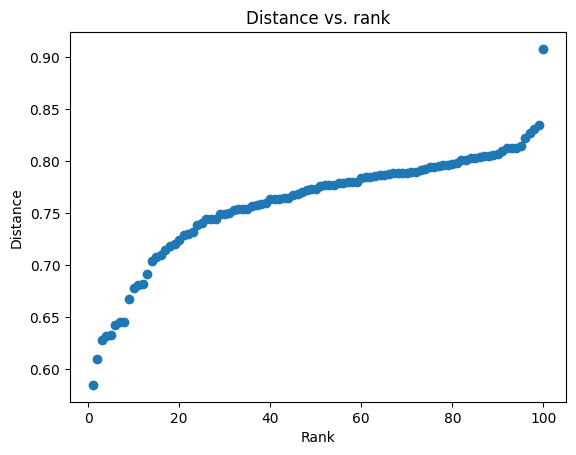

In [15]:
def plot_dists(dists, ylabel='Distance', title='Distance vs. rank'):
  ranks = range(len(dists))
  ranks = [x+1 for x in ranks]
  plt.scatter(x=ranks, y=list(dists));
  plt.xlabel('Rank');
  plt.ylabel(ylabel);
  plt.title(title);

faiss.normalize_L2(embeddings_test)

k=100
index_IVFL2_index = faiss.extract_index_ivf(index_IVFL2_PQ)
index_IVFL2_index.nprobe = 128
%time dist, indx = index_IVFL2_PQ.search(embeddings_test[0,:].reshape(1,D), k=k)
dense_distance = pd.Series(dist[0], index=indx[0])
#print("\nIndex and distances")
#print(dense_distance)

plot_dists(dense_distance)

> **Exercise 5-04:** You can see the nearest neighbor distances of the plot texts in ascending order, along with the indexes of the vectors.
> 1. What does the shape of the distance curve, including limited range of values, tell you about the relationship of the semantic similarity of the results of this query?    
> 2. Consider the role of the indices. How does the index help identify the movies to return as the results of the query?       

> **Answers:**
> 1. The shape of the curve shows an upward trend that increases with rank, meaning that as rank increases the similarity decreases. The first 20 ranks (the most similar results) show clear differences between the results, which could indicate a stronger relationship of the first results to the queried plot. Then we see a gradual increase in distance between ranks 20-90. However, the range is narrow, which makes sense as we're dealing with semantically similar content (the plot of a movie is usually written in a similar way in terms of structure and vocabulary).
> 2.  The indices help us perform fast ANN similarity search. We have an index with OPQ applied for better compression, a IVFPQ to divide the space into `n_list=4096` Voroni regions and a PQ step to compress the vectors within the clusters, and a final exact (flat) search for the top candidates. When we search, the query embeddings (in this case, the plot of the movie we want to find the most similar movies to) are compared against the `nprobe=128` most relevant Voroni regions, and then we use the compressed (PQ) embeddings to get the approximate distance calculations, which are refined with a flat search on the top candidates. 

The code in the cell below displays the movie title, the cosine distance from the query embedding vector to the movie plot embedding vector, and the movie plot text. Execute this code and examine the results.  

In [16]:
def print_movies_distances(movies, line_length=100):
    for idx in movies.index:
      print("Title: " + movies.loc[idx,'Title'] + "\nDistance: " + str(movies.loc[idx,'Distance']))
      print(textwrap.fill(movies.loc[idx,'Plot'],  width=line_length))
      print('\n')


results = movie_plots.loc[indx[0], ['Title', 'Plot']]
results['Distance'] = dist[0]
print_movies_distances(results.iloc[:10,:])

Title: Caterpillar
Distance: 0.58502835
film set late second sinojapanese war first scene lieutenant kurokawa scourges rapes disembowels
chinese people war later returns home war hero horribly mutilated body alive reduced torso limbs
deaf mute burns covering half face three medals chest despite condition still constantly eager sex
performs acrobatically wife sexual acts rough imposed wife repelled nevertheless feels duty take
care film concludes disabled veteran kurokawa committing suicide dragging pond outside home


Title: Tiktik: The Aswang Chronicles
Distance: 0.6100409
makoy dingdong dantes arrogant illmannered playboy manila travels unnamed province get town
pulupandan effort make amends pregnant girlfriend sonia lovi poe sonias mother fely janice de belen
unhappy arrival immediately asks leave sonia likewise asks leave intending break relationship raise
child makoy calls one friends back manila store next door convinced make another attempt
reconciliation store owner pacing rina

We have found the 10 movies that have the smallest cosine distance to the query. It is clearly subjective if these results represent similar movies from a human perspective.    

## Search with User Query

As another experiment with vector search, we will try a short natural language query. Users of a streaming service often create such queries when searching for content.   

The code in the cell below defines a short natural language query and performs a vector search on the embedding of this query. Execute this code and examine the results.

In [17]:
Sample_query = np.array(["Film with soldiers dealing with the transition from war to peace"])
Sample_query_embedded = model.encode(Sample_query)
faiss.normalize_L2(Sample_query_embedded)

index_IVFL2_index.nprobe = 128
k=10
%time dist, idx_query = index_IVFL2_PQ.search(Sample_query_embedded.reshape(1,D), k)

results2 = movie_plots_train.loc[idx_query[0], ['Title', 'Plot']]
results2['Distance'] = dist[0]
print_movies_distances(results2)

CPU times: user 6.35 ms, sys: 0 ns, total: 6.35 ms
Wall time: 6.37 ms
Title: In Love and War
Distance: 0.6874101
film traces progress three marines shore leave world war ii pacific one men nico jeffrey hunter
seasoned decorated sergeant second frankie robert wagner perennial goofoff drinks much third alan
bradford dillman intellectual wealthy family joined marines despite fathers protests nico frankie
alan come san francisco furlough war nico proposes marries pregnant girlfriend andrea hope lange
drunken frankie fights charlie stanton hateful stepfather thinks coward wealthy alan catches fiancee
sue dana wynter another man lorraine sheree north love frankie joined military wave introduces
friend alan roommate kalai france nuyen nurse hawaiianfrench heritage go lorraines apartment frankie
first passes wakes screaming thought returning war lorraine decides leave kalai professes love alan
three men return pacific front frankie initially shows cowardice nico slaps sense later frankie
saves

As with the first query experiment, the evaluation of these results is quite subjective. From a human perspective it is hard to determine if these movies are a good match to the query.  

## Reranking Transformers   

As one would expect, approximate nearest neighbor search will generally not produce the best search results. Therefore, a reranking step is often applied to find a shorter list best results from a long list produced by ANNS.   

There are several possible whys to construct a search and reranking pipeline to produce improved search results. You can find a summary of reranking at scale oriented toward RAG algorithms in [this post from Pinecone](https://www.pinecone.io/learn/series/rag/rerankers/). In summary two of several possible approaches are:    
1. A sparse vector search is followed by a dense vector search. The sparse search acts as a filter on key words in the query. The dense vector search refines these results. While this approach yield results with high precision and recall, the sparse search can be slow at massive scale.  
2. A scaleable, ideally $O(log\ n)$, dense ANNS search followed by a reranking based on of a shortened list using a pairwise comparison search. The $O(n)$ complexity of the pairwise search is therefore limited to the top $k$ results of the ANNS search. We take this approach here.  



Specifically in this case, we will use the [CrossEncoder](https://sbert.net/examples/cross_encoder/applications/README.html) from the Transformers package to compute pairwise similarity of our search results. To instantiate this model, execute the code in the cell below.

> **Note:** The pretrained model used in this case is only one of many [pretrained models](https://sbert.net/docs/cross_encoder/pretrained_models.html) available for CrossEncoders.

In [18]:
pretrained_model = "cross-encoder/ms-marco-MiniLM-L6-v2"
model_CrossEncoder = CrossEncoder(pretrained_model)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

The `compute_scores` function defined below iterates over the pairwise distance calculation between the embedded query and the embedded target movie plots. Execute this code to compute the pairwise score or distances.    

In [19]:
def compute_scores(model, query, targets):
  scores = []
  for string in targets:
    scores.append(model.predict([(query, string)])[0])
  return scores

query_index = movie_plots_test.index[0]
scores = compute_scores(model_CrossEncoder, movie_plots_test.loc[query_index,'Plot'], results.loc[:,'Plot'])
scores[:10]

[-6.388839,
 -5.6581745,
 -6.8593745,
 -6.397297,
 -6.217818,
 -7.2637353,
 -5.8023853,
 -5.655263,
 -6.4458137,
 -6.085224]

As a final step, the code in the cell below adds the scores column to the data frame and performs a sort in descending order of distance to produce and displayed the top 10 reranked matches. Execute this code and examine the results.

In [20]:
## Sort the results data frame based on assending scores
results['Score'] = scores
results.sort_values(by='Score', ascending=False, inplace=True)
results.iloc[:10,:]

,Title,Plot,Distance,Score
2327,Wise Girl,susan fletcher miriam hopkins millionaire fath...,0.787377,-3.339331
12898,Albino Alligator,brothers dova matt dillon milo gary sinise sma...,0.770611,-5.066132
4137,This Man's Navy,world war ii chief aviation pilot ned trumpet ...,0.785037,-5.276200
6909,Sweet Smell of Success,manhattan press agent sidney falco tony curtis...,0.796100,-5.435437
15995,Cedar Rapids,naive idealistic insurance agent tim lippe wel...,0.718986,-5.465970
22684,Unbeatable,ching fai nick cheung former boxing champion s...,0.794741,-5.468495
22829,Call of Heroes,china devolved patchwork competing military go...,0.729852,-5.468862
3721,Ali Baba and the Forty Thieves,story begins immediate aftermath successful mo...,0.752879,-5.504220
8144,The Shooting,willet gashade oates former bounty hunter retu...,0.714427,-5.556193
9024,The Conversation,harry caul surveillance expert runs company sa...,0.764473,-5.636538


> **Exercise 5-05:** Examine these results and answer the following questions:
> 1. Why is the cross encoder a good choice for reranking, but would not be suitable for the initial retrieval step.
> 2. What quantitative evidence can you see in the table above of the effect of reranking?   

> **Answers:**
> 1. In short: the CrossEncoder is more accurate but more computationally expensive. It processes the query and the document together, which means that it is able to capture more intricate semantic relationships than caluclating the dot product (cosine similarity in this case, given that it is normalized) between the embeddings. However, it is O(n) for the pairwise comparisons, meaning that is not feasible for massive scale applications. This is why we use ANNS for the initial retrieval: the query time is sublinear, and then we get more accurate results with the more expensive reranking models.            
> 2. The distance results are very different to the reranking scores. Out of the top 10 reranked movies, Wise Girl (the 1st one) is one of the worst when looking at the distance. The best one with the distance metric (at least from the top 10 from the reranking), The Shooting, is the 9th one after reranking. The reranking significantly reordered the results!         

## Sparse Coding and Hybrid Coding     

So far we have only used dense embedding using SentanceTransformers which provides semantic similarity scores. However, dense encoding tends to have low sensitivity to specific terms in the query. Sparse embedding is another powerful approach which computes scores sensitive to specific terms. But, sparse embedding does not account for semantics.  

It is possible to combine the strength of both dense and sparse embedding . In the following we will create a hybrid indexer by using FAISS with dense embedding and BM25 for sparse embedding. For this hybrid recommender, the two algorithms are run in parallel. A hybrid score is computed by weighting and summing the scores from the two algorithms.

Since sparse embedding of a large corpus can be slow and memory intensive, we focus here on using it for reranking. Specifically we will do the following.  
1. Start with the top 1000 most similar plots to the query as determined by the dense search using FAISS.
2. Sparse embed the plot summaries of the 1000 movies using the BM25 algorithm.
3. Embed the query plot using BM25.
4. Score the similarity between the query and the 1000 movie plots.
5. Combine the scores from BM25 embedding with the cross-encoder scores computed in the foregoing section.    

### Tokenize and sparse embed movie plots     

We will now apply the BM25 algorithm to sparse embed the the text of the movie plots. There are two steps.        
1. For the The BM25 algorithm operates on tokenized text. The code in the cell below applies a simple tokenization to the text, using white-space between words.      
2. The tokenized text is sparse encoded using the (Okapi BM25 algorithm)[https://en.wikipedia.org/wiki/Okapi_BM25]. The code uses (BM25Okapi function from the[link text](https://) Rank-BM25 package)[https://github.com/dorianbrown/rank_bm25]

Execute this code.      

In [21]:
def tokenize_text(text_list):
  out = []
  for string in text_list:
    out.append(word_tokenize(string))
  return out


## Tokenize the plot text
tokenized_corpus = tokenize_text(list(movie_plots_train.loc[dense_distance.index,'Plot']))

## Sparse encode the tokenized documents
bm25 = BM25Okapi(tokenized_corpus)


### Query the BM25 sparse coding        

With the sparse inverted index constructed we can now perform efficient queries. The `bm25_query` function does the following.      
1. Tokenizes the text.     
2. Computes the scores for each to the of the embedded plots.   
3. Standardize the scores.    

Execute this code and examine the results.  

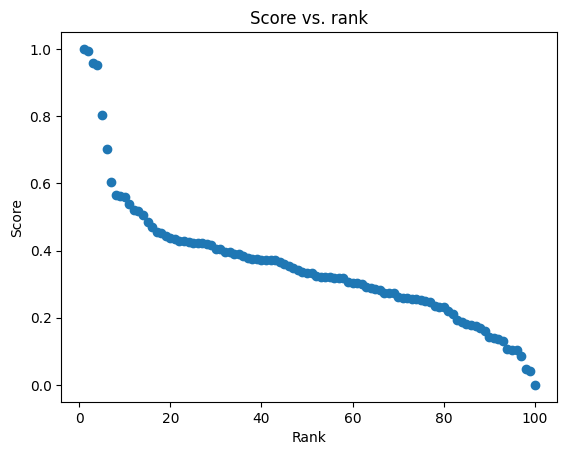

In [22]:
def bm25_query(model, query_text):
  tokenized_query = word_tokenize(query_text)
#  tokenized_query = query_text.split(" ")
  scores = model.get_scores(tokenized_query)
  scores =(scores - np.min(scores)) / (np.max(scores) - np.min(scores))
  return pd.Series(scores)

scores = bm25_query(bm25, movie_plots_test.loc[0,'Plot'])
plot_dists(scores.sort_values(ascending=False), ylabel='Score', title='Score vs. rank')

### Compute the hybrid score    

We will now compute the hybrid approximate similarity score, integrating the sparse embedding and dense embedding scores.    

The first step is to standardize the two scores. Standardizing the scores is critical since one does not want differences in their numeric ranges to bias the integrated result. Execute the code to apply a scalar to the two score vectors.  

In [23]:
results.loc[:,'BM25_scores'] = list(scores)

cols_to_scale = ['Score','BM25_scores']
scaler = StandardScaler()
results[cols_to_scale] = scaler.fit_transform(results[cols_to_scale])

results[['Score','BM25_scores']]

,Score,BM25_scores
2327,5.190818,0.471071
12898,2.178291,0.693804
4137,1.811811,0.990599
6909,1.534012,3.455444
15995,1.480744,3.198941
...,...,...
3501,-1.365027,-0.886464
4333,-1.456931,0.104614
18792,-1.475063,0.433742
26990,-1.518628,-1.891438


With the scores standardized, they can now be integrated into a hybrid score. Here we use a simple approach, an equal weight sum of the standardized scores. Execute the code and examine the results.  

In [24]:
sparse_weight = 0.5

integrated_scores = np.add(sparse_weight * results['BM25_scores'], (1 - sparse_weight) * results['Score'])
hybrid_scores = integrated_scores.sort_values(ascending=False)
hybrid_scores

,0
2327,2.830945
6909,2.494728
15995,2.339843
3721,2.319317
10446,2.237604
...,...
3501,-1.125745
25786,-1.241452
20651,-1.269233
29687,-1.541752


Finally, you can examine the top similarity matches by executing the code in the cell below.   

,Title,Plot,Distance,Score,BM25_scores,hybrid_scores
2327,Wise Girl,susan fletcher miriam hopkins millionaire fath...,0.787377,5.190818,0.471071,2.830945
12898,Albino Alligator,brothers dova matt dillon milo gary sinise sma...,0.770611,2.178291,0.693804,2.494728
4137,This Man's Navy,world war ii chief aviation pilot ned trumpet ...,0.785037,1.811811,0.990599,2.339843
6909,Sweet Smell of Success,manhattan press agent sidney falco tony curtis...,0.796100,1.534012,3.455444,2.319317
15995,Cedar Rapids,naive idealistic insurance agent tim lippe wel...,0.718986,1.480744,3.198941,2.237604
22684,Unbeatable,ching fai nick cheung former boxing champion s...,0.794741,1.476339,1.094605,1.793256
22829,Call of Heroes,china devolved patchwork competing military go...,0.729852,1.475700,0.357623,1.436047
3721,Ali Baba and the Forty Thieves,story begins immediate aftermath successful mo...,0.752879,1.414014,3.224619,1.401205
8144,The Shooting,willet gashade oates former bounty hunter retu...,0.714427,1.323344,0.273527,1.285472
9024,The Conversation,harry caul surveillance expert runs company sa...,0.764473,1.183176,2.403335,0.980681


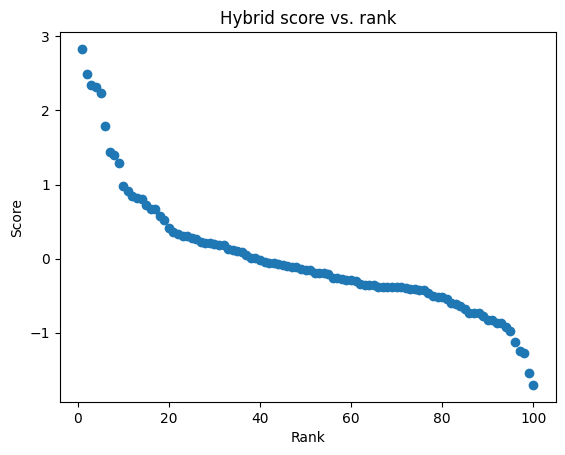

In [25]:
## Sort the results data frame based on assending scores
results.loc[:,'hybrid_scores'] = list(hybrid_scores)
results.sort_values(by='hybrid_scores', ascending=False, inplace=True)
plot_dists(results.loc[:,'hybrid_scores'].sort_values(ascending=False), ylabel='Score', title='Hybrid score vs. rank')
results.iloc[:10,:]

> **Exercise 5-06:** Examine the results computed with the hybrid reranker and answer these questions.
> 1. Comparing the scores for the dense cross-embedding, the sparse embedding and the hybrid of the two what can you say about the independence of these scores? How does the independence, or not, of the scores affect the independence of the hybrid score?
> 2. Compare the curves of the BM25 scores and the hybrid score. What does the difference tell you about the effectiveness of the hybrid score for ranking.        
> 3. Consider the trade-off hyperparameter `sparse_weight`. How will increasing or decreasing this hyperparameter change the resulting hybrid score?
> 4. Earlier we applied preprocessing to the movie plot text to a) set all characters to lower case, b) remove numbers, c) remove stop words, and d) remove punctuation. How do these preprocessing steps help to improve the similarity scores computed using the sparse embeddings?
> 5. An alternative to using the BM25 algorithm is to create sparse embeddings with a more sophisticated algorithm like SPLADE. What are the advantages and disadvantages of such an approach compared to the one applied here?     

> **Answers:**
> 1. The dense cross-embedding and the sparse embedding scores are not entirely independent, there is some correlation albeit weak. The CrossEncoder captures the semantic similarity (the meaning of the content, in this case the plot), and the BM25 sparse enbedding captures more an exact overlap of the words. We can see different results in the ranking, so we can say the information they use is complementary (not entirely independent, but not completely correlated). In this case, the hybrid score depends on both, so it is not independent, and depends on the weights we assign to each score. In this case, with equal weights, it depends equally on both representations, making it a more stable score (it can compensate when one representation misses something that the other one captures). This being an unsupervised learning task, it can be challenging to evaluate the results, as there is no ground truth to compare against.         
> 2. The BM25 curve is steeper, it emphasizes more the top matches, while the hybrid curve is smoother (not orders of magnitude, but sufficient enough to notice). This can mean that the hybrid scores are more balanced, as it is not over emphasizing the results of either representation, but smoothing out the differentiation between ranks by balancing both scores. 
> 3. With a hybrid score of `sparse_weight * results['BM25_scores'], (1 - sparse_weight) * results['Score']`, increasing `sparse_weight` (up from 0.5, which is equal weighting) would emphasize more the sparse embedding (BM25) score, meaning the resulting score would favor exact term matching rather than contextual semantic matching. Decreasing it would favor the dense cross-embedding score, which would match better the "conceptual" (more context related) queries but might miss some exact term matches.   
> 4. By applying those preprocessing steps, we are removing noise from the sparse embedding space. So "Director" and "director" would count as the same word, we remove tokens that don't add much to the overall content (like stop words or numbers or punctuation). The result of this is, since BM25 relies on exact word matching, we allow the model to focus on the relevant content words and get more comparable embeddings, improving the reliability and accuracy of the score. 
> 5. SPLADE models use term expansion, meaning they calculate the similarity search not only on exact word matches like BM25, but use synonyms or other relationships between words that it has learned from the vocabulary. This means that we get more accurate results, as we capture a broader "meaning" of the content and compare that instead of just looking at exact word overlap. As always, however, it comes at the expense of computation time/cost. It is more expensive, with O(n) complexity that increases time by a fixed constant, which is why we end up using either dense/sparse embeddings to get the initial retrieval, and then use SPLADE to improve the similarity score.  

## Adding Additional Features     

Up to now, we have only dealt with a single attribute of a movie, a plot summary, for similarity search. However, there are other attributes of the movie generally available in the dataset. Including . Adding embeddings of other movie attributes can lead to better similarity matches. Such an approach is common in solutions such as [**content-based recommender systems**](https://en.wikipedia.org/wiki/Recommender_system).       

### Exploring the variables

To get started, let's examine the data types of other movie attribute variables. Execute the code in the cell below and examine the results.

In [26]:
movie_plots.dtypes


,0
Release Year,int64
Title,object
Origin/Ethnicity,object
Director,object
Cast,object
Genre,object
Wiki Page,object
Plot,object


With the exception of the release date, all of the other attributes are text strings.    

To further explore these attributes, let's look at a sample of these attributes. Execute the code in the cell below and examine the results.    

In [27]:
for col in ['Release Year','Origin/Ethnicity', 'Director', 'Cast','Genre']:
  print('\n\n' + col)
  print(movie_plots.loc[:20,col])



Release Year
0     1901
1     1901
2     1901
3     1901
4     1902
5     1903
6     1903
7     1904
8     1905
9     1905
10    1906
11    1906
12    1906
13    1907
14    1907
15    1907
16    1908
17    1908
18    1908
19    1908
20    1908
Name: Release Year, dtype: int64


Origin/Ethnicity
0     American
1     American
2     American
3     American
4     American
5     American
6     American
7     American
8     American
9     American
10    American
11    American
12    American
13    American
14    American
15    American
16    American
17    American
18    American
19    American
20    American
Name: Origin/Ethnicity, dtype: object


Director
0                                      Unknown
1                                      Unknown
2                                      Unknown
3                                      Unknown
4           George S. Fleming, Edwin S. Porter
5                               Cecil Hepworth
6                              Edwin S. Porter
7        

Notice that these attributes are coded as short text strings, such as names of key words. There are also a number of missing values.       

The next question to ask is, what is the cardinality of these attributes? To find out, execute the code in the cell below and examine the results.  

In [28]:
for col in ['Origin/Ethnicity', 'Director', 'Cast','Genre']:
  print('\n\n' + col)
  print(len(movie_plots.loc[:,col].unique()))



Origin/Ethnicity
24


Director
12593


Cast
32183


Genre
2265


Several of these attributes have high cardinality.    

The Origin/Ethnicity variable has low cardinality, but what about case (class) imbalance? To find out, execute the code in the cell below and examine the results.   

In [29]:
movie_plots['counts'] = 1
movie_plots.loc[:,['counts', 'Origin/Ethnicity']].groupby(['Origin/Ethnicity']).agg('count')

,counts
Origin/Ethnicity,
American,17377
Assamese,9
Australian,576
Bangladeshi,87
Bengali,306
Bollywood,2931
British,3670
Canadian,723
Chinese,463


Notice that several of these classes have very few cases, whereas others have many cases.     

### Identifying and treating missing values

To continue the exploration of the data we will now explore missing values. One issue that must be dealt with is that the coding of missing values is inconsistent between the different attribute variables.       

To start the exploration of missing values execute the code in the cell below and examine the results.

In [30]:
for col, missing in zip(['Director', 'Genre'], ['Unknown', 'unknown']):
  print('\n' + col)
  print(len(movie_plots.loc[movie_plots.loc[:,col] == missing,col]))


Director
1124

Genre
6083


To continue the exploration of missing values, execute the code in the cell below.   

In [31]:
print(sum(movie_plots.loc[:,'Cast'].isna()))

1422


In order to process these unstructured variables we need to use a consistent coding for the missing values. The code in the cell below codes missing values in two variables to the string 'unknown'.

In [32]:
movie_plots_train.loc[movie_plots_train.loc[:,'Cast'].isna(),'Cast'] = 'unknown'
movie_plots_train.loc[movie_plots_train.loc[:,'Director'] == 'Unknown','Director'] = 'unknown'

### Embed the features      

With the attribute variables explored and prepared we are now ready to create an embedding. There are several reasonable paths we can take at this point:     
1. **Embed each variable independently** and then apply appropriate weights to combine the results. This approach has the advantage of flexibility at the cost of speed and complexity.     
2. **Embed the concatenated text strings** of these features and then embed. This approach lacks flexibility but is simple and faster, so we will adopt it here.      

To create the concatenated text strings, execute the code in the cell below.  

In [33]:
space_vector_train = np.array([' '] * movie_plots_train.shape[0])
space_vector_test = np.array([' '] * movie_plots_test.shape[0])

movie_plots_train['meta_information'] = movie_plots_train.loc[:,'Director'] + \
                                  space_vector_train + \
                                  movie_plots_train.loc[:,'Cast'] + \
                                  space_vector_train + \
                                  movie_plots_train.loc[:,'Origin/Ethnicity'] + \
                                  space_vector_train + \
                                  movie_plots_train.loc[:,'Genre'] + \
                                  space_vector_train + \
                                  movie_plots_train.loc[:,'Release Year'].to_string(index=False)

movie_plots_test['meta_information'] = movie_plots_test.loc[:,'Director'] + \
                                  space_vector_test + \
                                  movie_plots_test.loc[:,'Cast'] + \
                                  space_vector_test + \
                                  movie_plots_test.loc[:,'Origin/Ethnicity'] + \
                                  space_vector_test + \
                                  movie_plots_test.loc[:,'Genre'] + \
                                  space_vector_test + \
                                  movie_plots_test.loc[:,'Release Year'].to_string(index=False)


movie_plots_test.loc[:10,'meta_information']

,meta_information
0,"Henry Koster Deanna Durbin, Adolphe Menjou, Al..."
1,"Franc Roddam Billy Wirth, Kevin Dillon America..."
2,"Joe May Cedric Hardwicke, Vincent Price, Nan G..."
3,"Nora Ephron Tom Hanks, Meg Ryan, Ross Malinger..."
4,"Raj Babu Dileep, Roma, Vinu Mohan, Bhama, Inno..."
5,Unknown Govinda Bollywood unknown 1937\n1988\n...
6,"Lesley Selander Philip Friend, Wanda Hendrix A..."
7,"Val Guest Jack Warner, Ronald Lewis British cr..."
8,"Robert Iscove Freddie Prinze Jr., Rachael Leig..."
9,Shōhei Imamura Kōji Yakusho\r\nMisa Shimizu\r\...


### Embed the features      

We are now ready to embed the concatenated movie meta-attributes. To proceed, execute the code in the cell below.        

In [34]:
model_meta =  SentenceTransformer(
    sentence_model,
    similarity_fn_name='cosine',
    device=device
)

%time embeddings_meta_train = model_meta.encode(movie_plots_train.loc[:,'meta_information'].to_numpy())
%time embeddings_meta_test = model_meta.encode(movie_plots_test.loc[:10,'meta_information'].to_numpy())

print(embeddings_meta_train.shape)
print(embeddings_meta_test.shape)

CPU times: user 2h 6min 12s, sys: 7.55 s, total: 2h 6min 20s
Wall time: 19min 26s
CPU times: user 197 ms, sys: 4 µs, total: 197 ms
Wall time: 104 ms
(33839, 768)
(11, 768)


In [ ]:
#%time embeddings_meta_test = model_meta.encode(movie_plots_test.loc[:10,'meta_information'].to_numpy())
#print(embeddings_meta_test.shape)

The next step is to concatenate the embedding of the plot summaries and the embeddings of the movie attributes into a single embedding vector.

In [35]:
concatenated_embeddings_train = np.concatenate((embeddings_train, embeddings_meta_train), axis=0)
concatenated_embeddings_test = np.concatenate((embeddings_test, embeddings_meta_test), axis=0)

print(concatenated_embeddings_train.shape)
print(concatenated_embeddings_test.shape)

(67678, 768)
(1058, 768)


The embeddings are now of dimension 768.    

### Perform the similarity search     

With the embedding created the index can now be constructed from the training embeddings. Execute this code to build the index. Execution will take a significant amount of time.     

In [36]:
# L2 normalize the training vectors to get cosine distance from L2 dot product distance
faiss.normalize_L2(concatenated_embeddings_train)

# Build the index
D=concatenated_embeddings_train.shape[1]
m = 64
nbits = 8
nlist = 4096
index_IVFL2_PQ = build_index(D, m, nbits, nlist)

# Train the index and add the vectors
%time index_IVFL2_PQ.train(concatenated_embeddings_train)
index_IVFL2_PQ.add(concatenated_embeddings_train)
print(f'Index size: {get_memory(index_IVFL2_PQ)} MB')

CPU times: user 3h 22min 42s, sys: 3.99 s, total: 3h 22min 46s
Wall time: 21min 4s
Index size: 228.54 MB


The code in the cell below performs a query using the additional attribute features. Execute the code in the cell below.  

In [37]:
faiss.normalize_L2(concatenated_embeddings_test)

k=100
index_IVFL2_index = faiss.extract_index_ivf(index_IVFL2_PQ)
index_IVFL2_index.nprobe = 128
%time dist, indx = index_IVFL2_PQ.search(concatenated_embeddings_test[0,:].reshape(1,D), k=k)


results = movie_plots_train.loc[indx[0], ['Title', 'Plot']]
results['Distance'] = dist[0]
print_movies_distances(results.iloc[:10,:])


CPU times: user 6.42 ms, sys: 0 ns, total: 6.42 ms
Wall time: 6.43 ms
Title: Phantom of the Opera
Distance: 0.58502835
violinist erique claudin dismissed paris opera house revealing losing use fingers left hand
unbeknownst conductor assumes claudin able support musician used money help anonymously fund voice
lessons christine dubois young soprano fallen love desperate attempt earn money claudin submits
piano concerto written publication submitting hearing response becomes worried returns publishers
pleyel desjardins ask one knows happened seem care claudin persists maurice pleyel rudely tells
leave goes back etchings working finally giving claudin stands moment hangs head sadly someone
begins play music next room looks shock hears concerto merely endorsed praised franz liszt convinced
pleyel trying steal concerto claudin leaps begins strangle tosses body pleyel floor georgette
publishers assistant throws etching acid claudin screaming wailing dashes door clutching face hunted
police mu

> **Exercise 5-07:**  Now, answer these questions.
> 1. As explained, we do not have independent ranking information for this data set, but we can make some qualitative conjectures about the quality of the ranking. Read the plot summaries and compare them to the plot summary of the query movie. Briefly describe the quality or general agreement of plot content between he query and the ranked responses.
> 2. Briefly explain how the addition attributes, such as genre, could have lead to better reposes to the queries.
> 3. Briefly explain how the missing or 'unknown' values in the attributes create ambiguity and reduce the recall of the query.    

> **Answer:**
> 1. Generally, there appears to be a strong thematic overlay between the test movie (One Hundred Men and a Girl) and the top similarity results. I had to go back and read the plots straight from Wikipedia (turns out stop words and uppercases exist for a reason, at least for us humans) to understand what the movie was about, and the main themes revolve around music, orchstras, musicians, conductors, and a woman who "is the daughter of a struggling musician who forms a symphony orchestra consisting of his unemployed friends" ([Wikipedia](https://en.wikipedia.org/wiki/One_Hundred_Men_and_a_Girl)). Most of the results have similar themes: Phantom of the Opera (music, musicians, opera performance, orchestras); La Boheme (musicians, performers), The Lady is a Square (a daughter, classical vs. modern music, musicians, orchestras), Humoresque (a violinist, friends, performance), among other examples.
> 1. There is an expected relationship in the content (plot) of movies with similar attributes. It is not wild to think that movies from the same genre, from a certain period or decade, with a similar origin and cast, can have thematic overlays. These attributes complement the pure semantic similarity, so we end up with a more robust ranking.
> 2. On one hand, if a movie is of the 'musical' genre like the one in the test example, and any other one is 'unknown', the model would find those different and might penalize the score even if the plot is similar. This makes the results ambiguous: the plot matches but the attributes don't, for example. So we rank them lower, which could result in lower recall. On the other hand, we might end up clustering movies with 'unknown' values in the attributes, making it much harder to find true relevant matches.      

The next step is to perform the reranking using the cross encoder. Execute the code in the cell below to perform the reranking and display the results.     

,Title,Plot,Distance,Score
13218,The Great Waltz,highly fictionalised story sees schani dismiss...,0.704099,-4.130676
23532,Amadeus,elderly antonio salieri confesses murder forme...,0.667562,-4.168772
22977,Street Girl,four seasons good jazz quartet perform new yor...,0.797218,-4.241637
32051,Hot Enough for June,roger allsop john le mesurier turns belongings...,0.824108,-4.251849
28714,The Lady Is a Square,mrs baring businesswoman patron classical musi...,0.627956,-4.312389
15251,Waltzes from Vienna,waltzes vienna begins sound fire brigade horn ...,0.807864,-4.383534
8122,Two for Tonight,crosby cast gilbert one three halfbrothers gil...,0.800888,-4.518557
8551,One in a Million,american showman thadeus spencer adolphe menjo...,0.763617,-4.607519
13027,Tales of Manhattan,tailcoat custom made renowned stage actor paul...,0.840481,-4.612462
10446,Broken Strings,concert violinist arthur williams clarence mus...,0.729280,-4.614066


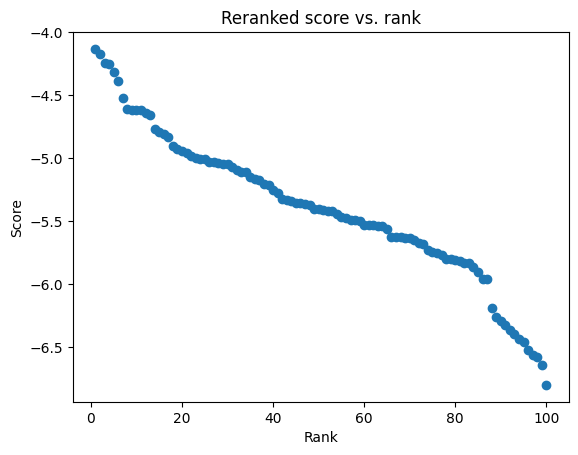

In [38]:
def compute_scores(model, query, targets):
  scores = []
  for string in targets:
    scores.append(model.predict([(query, string)])[0])
  return scores

pretrained_model = "cross-encoder/ms-marco-MiniLM-L6-v2"
model_CrossEncoder = CrossEncoder(pretrained_model)


query_index = movie_plots_test.index[0]
scores = compute_scores(model_CrossEncoder, movie_plots_test.loc[query_index,'Plot'], results.loc[:,'Plot'])
scores[:10]

# Sort the results data frame based on assending scores
results['Score'] = scores
results.sort_values(by='Score', ascending=False, inplace=True)
plot_dists(results.loc[:,'Score'], ylabel='Score', title='Reranked score vs. rank')
results.iloc[:10,:]

> **Exercise 5-08:** Examine the results of the distances and score and answer these questions.
> 1. Briefly explain what the respective ordering, or lack thereof, tell you about the the effect of the reranking?
> 2. Briefly explain what the shape of the curve and range of score values tell you about the reliability of the approximate nearest neighbor search results and the rankings.     
> 3. We have investigated using additional embedded attributes to improve approximate nearest neighbor search. Another possible way to improve search results is to filter the raw database by one or more categorical attribute. For example, in the case of movies the genre might be one way to do so. If you were to implement such a filter, what type of index or data structure would you use for efficient filtering at scale. What is a computational efficient approach to filter on keywords before doing the nearest neighbor search?

> **Answers:**      
> 1. As was the case without the metadata attributes, the distance ranking and the reranking score ranking are very different. The most similar movie (lowest rank and higher reranking score) didn't have the lowest distance, showing again that the CrossEncoder is capturing a different relationship that is not captured by the distance. The reranking is providing new information, and shows why we might need a hybrid score that balances out these results to get a more robust similarity ranking.       
> 2. The top 15 results are well differentiated, suggesting those might be more reliable, while the 15-85 ranks show similar scores, which then decline with a steep end (lowest ranked results are less relevant). The spread is also reasonable, suggesting there is some level of differentiation found by the reranking model, at least from the top vs. the bottom results. It can be harder to differentiate the middle section, and we need to keep in mind that this reranking only ran on the top 100 results retrieved by the initial ANN search.   
> 3. Definitely an IVF, as it allows us to lookup by value. What we would need is a lookup table where we map the genre to the movies (in this case it can be to the plots/content, or the embedded metadata, or both). This process has sublinear complexity $ C << O(DN)$ that would significantly reduce the search space for the rest of the ANN search.         

#### Copyright 2025, Stephen F. Elston. All rights reserved.